In [10]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib as mpl

In [11]:
all_posts = pd.read_parquet(f"data/all_posts_data.parquet")
all_replies = pd.read_parquet(f"data/all_replies_data.parquet")

print(f"Posts: {len(all_posts):,}")
print(f"Replies: {len(all_replies):,}")

Posts: 261,501
Replies: 2,415,781


# Finding: Republican Posts use more toxic language than Democrat Posts

In [21]:
d_posts = all_posts[all_posts['political_leaning_pred'] == 'Democrat']['toxic']
r_posts = all_posts[all_posts['political_leaning_pred'] == 'Republican']['toxic']

stat_two, p_two = mannwhitneyu(d_posts, r_posts, alternative='two-sided')
_, p_r_greater = mannwhitneyu(r_posts, d_posts, alternative='greater')
_, p_d_greater = mannwhitneyu(d_posts, r_posts, alternative='greater')

print(f"Democrat posts   (n={len(d_posts):,}): median={d_posts.median():.3f}")
print(f"Republican posts (n={len(r_posts):,}): median={r_posts.median():.3f}")
print(f"MWU two-sided p={p_two}")
print(f"MWU R > D      p={p_r_greater}")
print(f"MWU D > R      p={p_d_greater}")
delta = 1 - 2*stat_two / (len(d_posts)*len(r_posts))
print(f"Cliff's delta (R > D): {delta:.3f}")

Democrat posts   (n=89,606): median=0.129
Republican posts (n=91,337): median=0.144
MWU two-sided p=5.384154358564588e-07
MWU R > D      p=2.692077179282294e-07
MWU D > R      p=0.999999730792408
Cliff's delta (R > D): 0.014


# Finding: Replies to Democrat Posts use more toxic language than replies to Republican Posts

In [22]:
replies_to_d = all_replies[all_replies['in_reply_to_status_id_str'].isin(
    all_posts[all_posts['political_leaning_pred'] == 'Democrat']['id']
)]['toxic']

replies_to_r = all_replies[all_replies['in_reply_to_status_id_str'].isin(
    all_posts[all_posts['political_leaning_pred'] == 'Republican']['id']
)]['toxic']

stat_two, p_two = mannwhitneyu(replies_to_d, replies_to_r, alternative='two-sided')
_, p_d_greater = mannwhitneyu(replies_to_d, replies_to_r, alternative='greater')
_, p_r_greater = mannwhitneyu(replies_to_r, replies_to_d, alternative='greater')

print(f"Replies to D posts (n={len(replies_to_d):,}): median={replies_to_d.median():.3f}")
print(f"Replies to R posts (n={len(replies_to_r):,}): median={replies_to_r.median():.3f}")
print(f"MWU two-sided    p={p_two}")
print(f"MWU D > R        p={p_d_greater}")
print(f"MWU R > D        p={p_r_greater}")
delta = 2*stat_two / (len(replies_to_d)*len(replies_to_r)) - 1
print(f"Cliff's delta (D > R): {delta:.3f}")

Replies to D posts (n=1,145,347): median=0.199
Replies to R posts (n=708,705): median=0.178
MWU two-sided    p=0.0
MWU D > R        p=0.0
MWU R > D        p=1.0
Cliff's delta (D > R): 0.038


# Figure 1: Post and Reply Toxicity by Partisanship

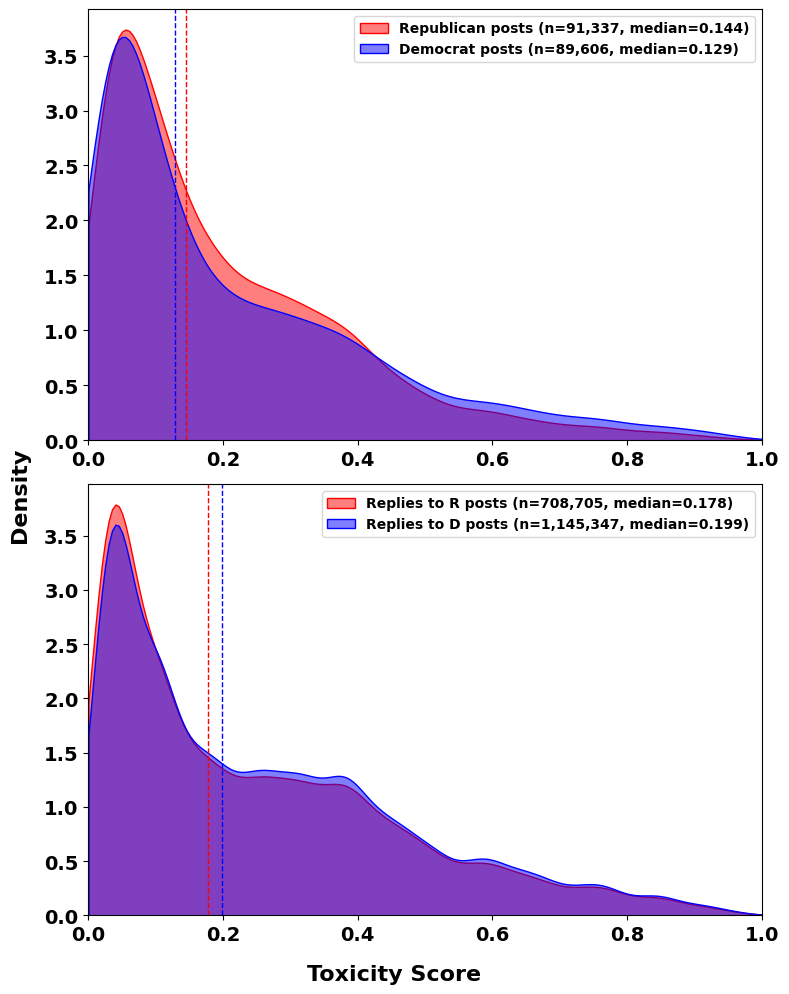

In [14]:
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Top panel: D vs R post toxicity
ax = axes[0]
sns.kdeplot(r_posts, ax=ax, color="red", fill=True, alpha=0.5, clip=(0, 1), bw_adjust=2,
            label=f"Republican posts (n={len(r_posts):,}, median={r_posts.median():.3f})")
sns.kdeplot(d_posts, ax=ax, color="blue", fill=True, alpha=0.5, clip=(0, 1), bw_adjust=2,
            label=f"Democrat posts (n={len(d_posts):,}, median={d_posts.median():.3f})")
ax.axvline(r_posts.median(), color="red", linestyle="--", linewidth=1)
ax.axvline(d_posts.median(), color="blue", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("")
ax.legend(fontsize=13, prop={"weight": "bold"})
ax.tick_params(labelsize=14)

# Bottom panel: replies to D vs R posts
ax = axes[1]
sns.kdeplot(replies_to_r, ax=ax, color="red", fill=True, alpha=0.5, clip=(0, 1), bw_adjust=2,
            label=f"Replies to R posts (n={len(replies_to_r):,}, median={replies_to_r.median():.3f})")
sns.kdeplot(replies_to_d, ax=ax, color="blue", fill=True, alpha=0.5, clip=(0, 1), bw_adjust=2,
            label=f"Replies to D posts (n={len(replies_to_d):,}, median={replies_to_d.median():.3f})")
ax.axvline(replies_to_r.median(), color="red", linestyle="--", linewidth=1)
ax.axvline(replies_to_d.median(), color="blue", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("")
ax.legend(fontsize=13, prop={"weight": "bold"})
ax.tick_params(labelsize=14)

fig.supxlabel("Toxicity Score", fontsize=16, fontweight="bold")
fig.supylabel("Density", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


# Finding: For replies to Republican Posts, Democrat replies are more toxic

In [23]:
replies_to_r_full = all_replies[all_replies['in_reply_to_status_id_str'].isin(
    all_posts[all_posts['political_leaning_pred'] == 'Republican']['id']
)]

r_replies_to_r = replies_to_r_full[replies_to_r_full['political_leaning_pred'] == 'Republican']['toxic']
d_replies_to_r = replies_to_r_full[replies_to_r_full['political_leaning_pred'] == 'Democrat']['toxic']

stat_two, p_two = mannwhitneyu(d_replies_to_r, r_replies_to_r, alternative='two-sided')
_, p_d_greater = mannwhitneyu(d_replies_to_r, r_replies_to_r, alternative='greater')
_, p_r_greater = mannwhitneyu(r_replies_to_r, d_replies_to_r, alternative='greater')

print(f"Republican replies to R posts (n={len(r_replies_to_r):,}): median={r_replies_to_r.median():.3f}")
print(f"Democrat replies to R posts   (n={len(d_replies_to_r):,}): median={d_replies_to_r.median():.3f}")
print(f"MWU two-sided  p={p_two}")
print(f"MWU D > R      p={p_d_greater}")
print(f"MWU R > D      p={p_r_greater}")
delta = 2*stat_two / (len(d_replies_to_r)*len(r_replies_to_r)) - 1
print(f"Cliff's delta (D > R): {delta:.3f}")

Republican replies to R posts (n=410,780): median=0.164
Democrat replies to R posts   (n=205,607): median=0.263
MWU two-sided  p=0.0
MWU D > R      p=0.0
MWU R > D      p=1.0
Cliff's delta (D > R): 0.193


# Finding: For replies to Democrat Posts, Republican replies are more toxic

In [24]:
replies_to_d_full = all_replies[all_replies['in_reply_to_status_id_str'].isin(
    all_posts[all_posts['political_leaning_pred'] == 'Democrat']['id']
)]

r_replies_to_d = replies_to_d_full[replies_to_d_full['political_leaning_pred'] == 'Republican']['toxic'].dropna()
d_replies_to_d = replies_to_d_full[replies_to_d_full['political_leaning_pred'] == 'Democrat']['toxic'].dropna()

stat_two, p_two = mannwhitneyu(r_replies_to_d, d_replies_to_d, alternative='two-sided')
_, p_r_greater = mannwhitneyu(r_replies_to_d, d_replies_to_d, alternative='greater')
_, p_d_greater = mannwhitneyu(d_replies_to_d, r_replies_to_d, alternative='greater')

print(f"Republican replies to D posts (n={len(r_replies_to_d):,}): median={r_replies_to_d.median():.3f}")
print(f"Democrat replies to D posts   (n={len(d_replies_to_d):,}): median={d_replies_to_d.median():.3f}")
print(f"MWU two-sided  p={p_two}")
print(f"MWU R > D      p={p_r_greater}")
print(f"MWU D > R      p={p_d_greater}")
delta = 2*stat_two / (len(r_replies_to_d)*len(d_replies_to_d)) - 1
print(f"Cliff's delta (R > D): {delta:.3f}")

Republican replies to D posts (n=756,671): median=0.237
Democrat replies to D posts   (n=257,773): median=0.156
MWU two-sided  p=0.0
MWU R > D      p=0.0
MWU D > R      p=1.0
Cliff's delta (R > D): 0.162


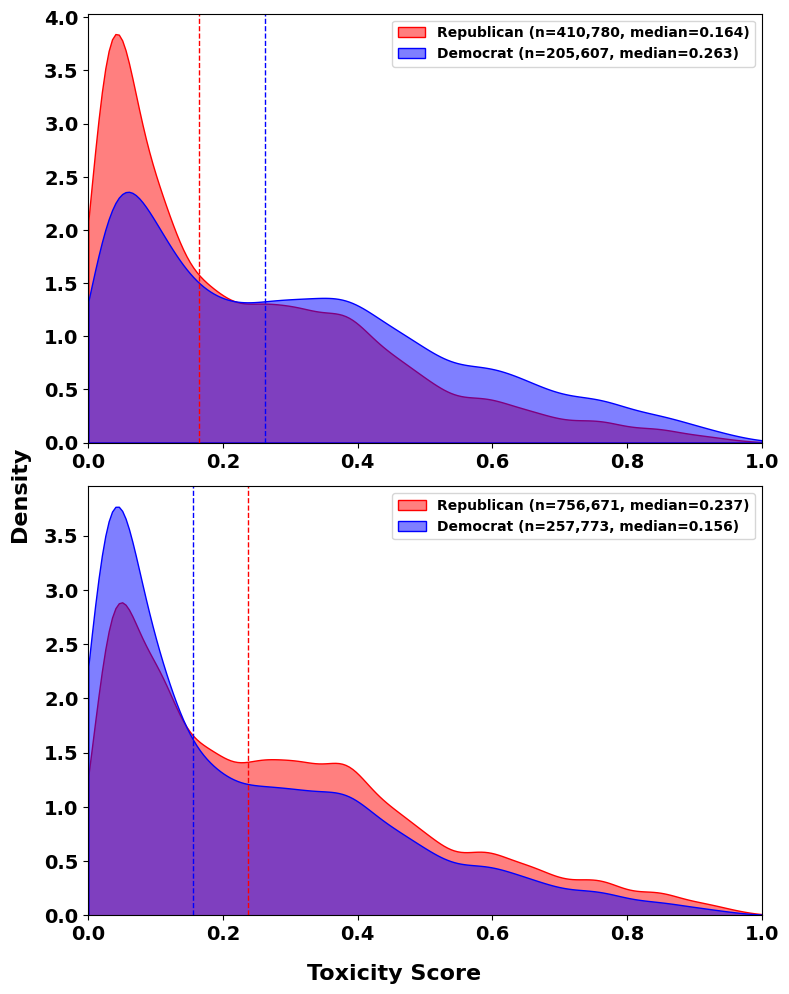

In [17]:
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

for ax, r_data, d_data in zip(axes, [r_replies_to_r, r_replies_to_d], [d_replies_to_r, d_replies_to_d]):
    sns.kdeplot(r_data, ax=ax, color="red", fill=True, alpha=0.5, clip=(0, 1), bw_adjust=2, label=f"Republican (n={len(r_data):,}, median={r_data.median():.3f})")
    sns.kdeplot(d_data, ax=ax, color="blue", fill=True, alpha=0.5, clip=(0, 1), bw_adjust=2, label=f"Democrat (n={len(d_data):,}, median={d_data.median():.3f})")
    ax.axvline(r_data.median(), color="red", linestyle="--", linewidth=1)
    ax.axvline(d_data.median(), color="blue", linestyle="--", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(fontsize=13, prop={"weight": "bold"})
    ax.tick_params(labelsize=14)

fig.supxlabel("Toxicity Score", fontsize=16, fontweight="bold")
fig.supylabel("Density", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


In [18]:
def majority_vote(labels):
    counts = labels.value_counts()
    if counts.empty:
        return None, False
    top_count = counts.iloc[0]
    is_tie = (counts == top_count).sum() > 1
    if is_tie:
        return 'Unsure', True
    return counts.idxmax(), False

results = all_replies.groupby('user_id')['political_leaning_pred'].agg(
    lambda x: majority_vote(x)
).reset_index()

results[['user_political_label', 'is_tie']] = pd.DataFrame(results['political_leaning_pred'].tolist(), index=results.index)
results = results.drop(columns=['political_leaning_pred']).rename(columns={'user_id': 'user_id'})

print(results['user_political_label'].value_counts())
print(f"\nTotal users: {len(results):,}")
print(f"Users with tie: {results['is_tie'].sum():,}")


user_political_label
Republican    439020
Unsure        157063
Democrat      154012
Name: count, dtype: int64

Total users: 750,095
Users with tie: 43,701


In [19]:
results

,user_id,user_political_label,is_tie
0,531,Democrat,False
1,614,Democrat,False
2,2053,Unsure,False
3,2806,Republican,False
4,3221,Unsure,False
...,...,...,...
750090,1854402560628752384,Republican,False
750091,1856562757966901248,Republican,False
750092,1857126761089118208,Republican,False
750093,1857159782383091712,Republican,False


In [20]:
# Users who replied to Democrat posts
users_replying_to_d = all_replies[all_replies['in_reply_to_status_id_str'].isin(
    all_posts[all_posts['political_leaning_pred'] == 'Democrat']['id']
)].merge(results[['user_id', 'user_political_label']], on='user_id', how='inner')

r_users_to_d = users_replying_to_d[users_replying_to_d['user_political_label'] == 'Republican']['user_id'].nunique()
d_users_to_d = users_replying_to_d[users_replying_to_d['user_political_label'] == 'Democrat']['user_id'].nunique()

# Users who replied to Republican posts
users_replying_to_r = all_replies[all_replies['in_reply_to_status_id_str'].isin(
    all_posts[all_posts['political_leaning_pred'] == 'Republican']['id']
)].merge(results[['user_id', 'user_political_label']], on='user_id', how='inner')

r_users_to_r = users_replying_to_r[users_replying_to_r['user_political_label'] == 'Republican']['user_id'].nunique()
d_users_to_r = users_replying_to_r[users_replying_to_r['user_political_label'] == 'Democrat']['user_id'].nunique()

print(f"Unique R users replying to D posts: {r_users_to_d:,}")
print(f"Unique D users replying to D posts: {d_users_to_d:,}")
print(f"\nUnique R users replying to R posts: {r_users_to_r:,}")
print(f"Unique D users replying to R posts: {d_users_to_r:,}")
print(f"\nCross-partisan ratio (R→D vs D→R): {r_users_to_d/d_users_to_r:.1f}:1")


Unique R users replying to D posts: 269,595
Unique D users replying to D posts: 92,975

Unique R users replying to R posts: 188,439
Unique D users replying to R posts: 74,081

Cross-partisan ratio (R→D vs D→R): 3.6:1


# Classifier Validation (Gold Standard F1 Scores)

In [ ]:
from sklearn.metrics import classification_report, f1_score

labels = ['Democrat', 'Republican', 'Unsure']

gs_posts = pd.read_parquet("data/gold_standard_posts_384.parquet")
print("=== Post Classifier ===")
print(classification_report(gs_posts['final_label'], gs_posts['political_leaning_pred'], labels=labels, digits=3))
print(f"Macro F1: {f1_score(gs_posts['final_label'], gs_posts['political_leaning_pred'], labels=labels, average='macro'):.3f}")

print()

gs_replies = pd.read_parquet("data/gold_standard_replies_384.parquet")
print("=== Reply Classifier ===")
print(classification_report(gs_replies['final_label'], gs_replies['political_leaning_pred'], labels=labels, digits=3))
print(f"Macro F1: {f1_score(gs_replies['final_label'], gs_replies['political_leaning_pred'], labels=labels, average='macro'):.3f}")

=== Post Classifier ===
              precision    recall  f1-score   support

    Democrat      0.766     0.847     0.804       131
  Republican      0.826     0.788     0.807       156
      Unsure      0.611     0.567     0.588        97

    accuracy                          0.753       384
   macro avg      0.734     0.734     0.733       384
weighted avg      0.751     0.753     0.751       384

Macro F1: 0.733

=== Reply Classifier ===
              precision    recall  f1-score   support

    Democrat      0.944     0.835     0.886       121
  Republican      0.960     0.898     0.928       216
      Unsure      0.507     0.809     0.623        47

    accuracy                          0.867       384
   macro avg      0.804     0.847     0.812       384
weighted avg      0.900     0.867     0.878       384

Macro F1: 0.812
